# Analyse Experiment Results #

In [1]:
import os
import ast
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

## Analyse Dataset Selection Experiments with Negative Sampling & Smoothing Factor using Cold Start Setting (03/03)

In [2]:
## util methods ##

def parse_cell(x):
    """
    Convert a cell into a Python object.
    Handles cases where the cell is already a list
    or stored as a string representation of a list.
    """
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip()
        try:
            return ast.literal_eval(x)
        except Exception:
            try:
                return json.loads(x)
            except Exception:
                return None
    return x


def avg_fold_metrics(fold_value):
    """
    fold_value should be a list of 10 sublists, each sublist like:
    [auc, aupr, precision, sensitivity, specificity]

    Returns:
    [avg_auc, avg_aupr, avg_precision, avg_sensitivity, avg_specificity]
    """
    fold_value = parse_cell(fold_value)

    if not fold_value:
        return [np.nan] * 5

    arr = np.array(fold_value, dtype=float)   # shape should be (10, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [10]:
EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_.csv'
EXP_0803_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0803.csv'
EXP_0903_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0903.csv'

# preprocessed csv files name - for saving preprocessed results 
PREPROCESSED_EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_preprocessed_.csv'
PREPROCESSED_EXP_0803_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0803_full_preprocessed_.csv'
PREPROCESSED_EXP_0903_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0903_full_preprocessed_.csv'

In [11]:
exp_df = pd.read_csv(EXP_0903_PATH)
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5
0,dataset_neg_fct_3_smoo_fct_1.0,"{""fold1"": [[0.9831123100712652, 0.958444207098...","[[0.7404227233750593, 0.6951663848414211, 0.71...","[[0.8248539350253333, 0.7521563317123322, 0.76...","[[0.9008504684473673, 0.8895046819738608, 0.87...","[[0.96270170654751, 0.9455729236416158, 0.9464...","[[0.937140101617185, 0.9345654077799741, 0.947..."
1,dataset_neg_fct_4_smoo_fct_1.0,"{""fold1"": [[0.98738749985995, 0.95461976241106...","[[0.7848783612574812, 0.7021479882590884, 0.74...","[[0.8427420988698445, 0.7784911974621782, 0.80...","[[0.898459669609477, 0.8881022812930561, 0.910...","[[0.9520547720682905, 0.9369077458548204, 0.95...","[[0.9423809464010791, 0.9371475840686371, 0.95..."
2,dataset_neg_fct_5_smoo_fct_1.0,"{""fold1"": [[0.9881167154149739, 0.951470110779...","[[0.7514444899721586, 0.685895916916708, 0.744...","[[0.8559692015631991, 0.7932013765744989, 0.81...","[[0.9017055819557679, 0.8916297800247295, 0.93...","[[0.9645729063132261, 0.9492008529521156, 0.94...","[[0.946364561069517, 0.9420674016961431, 0.964..."
3,dataset_neg_fct_5_smoo_fct_0.9,"{""fold1"": [[0.9873508685852522, 0.949280141052...","[[0.79974605975034, 0.7016714245050533, 0.7621...","[[0.8069864621024218, 0.7527253852889065, 0.81...","[[0.8745478103463807, 0.8637124331691555, 0.91...","[[0.9661304462281273, 0.9514530709014837, 0.95...","[[0.9352591539603327, 0.931924253312124, 0.968..."


In [12]:
exp_df = exp_df.iloc[:, :].copy() # exclude experiments that still running
exp_df['exp']

0    dataset_neg_fct_3_smoo_fct_1.0
1    dataset_neg_fct_4_smoo_fct_1.0
2    dataset_neg_fct_5_smoo_fct_1.0
3    dataset_neg_fct_5_smoo_fct_0.9
Name: exp, dtype: object

In [13]:
exp_df.shape

(4, 7)

In [14]:
# add fold1_avg ... fold5_avg
for i in range(1, 6):
    exp_df[f"fold{i}_avg"] = exp_df[f"fold{i}"].apply(avg_fold_metrics)
exp_df.shape

(4, 12)

In [15]:
# add fold_statistics column; average over the 5 fold averages [auc, aupr, precision, sensitivity, specificity]
def compute_folds_statistics(row):
    '''
    creates folds statistic column which has the mean of each metric
    across all folds (and across its experiments) for auc, aupr,
    precision, sensitivity and specificity;
    [mean_auc_5_folds_experiments, mean_aupr_5_folds_experiments ...]
    # list order -> [auc, aupr, precision, sensitivity, specificity]
    '''
    fold_avgs = []
    for i in range(1, 6):
        val = row[f"fold{i}_avg"]
        val = parse_cell(val)
        if val is not None:
            fold_avgs.append(val)

    if not fold_avgs:
        return [np.nan] * 5

    arr = np.array(fold_avgs, dtype=float)   # shape (5, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [16]:
exp_df["folds_statistics"] = exp_df.apply(compute_folds_statistics, axis=1)
exp_df.shape

(4, 13)

In [17]:
# add AUC_statistics = [average_auc, variance_auc, std_auc]
# based on the 5 fold average AUCs: fold1_avg[0] ... fold5_avg[0]

def compute_auc_statistics(row):
    aucs = []
    for i in range(1, 6):
        fold_avg = parse_cell(row[f"fold{i}_avg"])
        if fold_avg is not None and len(fold_avg) > 0:
            aucs.append(float(fold_avg[0]))

    if not aucs:
        return [np.nan, np.nan, np.nan]

    aucs = np.array(aucs, dtype=float)
    return [
        float(np.mean(aucs)),
        float(np.var(aucs)),   # population variance
        float(np.std(aucs))    # population std
    ]

In [18]:
exp_df["AUC_statistics"] = exp_df.apply(compute_auc_statistics, axis=1)
exp_df.shape

(4, 14)

In [21]:
# round all columns (5 digits) ...
for col in [f"fold{i}_avg" for i in range(1, 6)] + ["folds_statistics", "AUC_statistics"]:
    exp_df[col] = exp_df[col].apply(
        lambda x: [round(v, 5) if pd.notna(v) else v for v in x] if isinstance(x, list) else x
    )
exp_df.shape

(4, 14)

In [22]:
exp_df.head(1)

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,dataset_neg_fct_3_smoo_fct_1.0,"{""fold1"": [[0.9831123100712652, 0.958444207098...","[[0.7404227233750593, 0.6951663848414211, 0.71...","[[0.8248539350253333, 0.7521563317123322, 0.76...","[[0.9008504684473673, 0.8895046819738608, 0.87...","[[0.96270170654751, 0.9455729236416158, 0.9464...","[[0.937140101617185, 0.9345654077799741, 0.947...","[0.73221, 0.69052, 0.71428, 0.19025, 0.92337]","[0.83938, 0.76676, 0.77729, 0.26825, 0.92321]","[0.89372, 0.88079, 0.87187, 0.44849, 0.93389]","[0.96148, 0.94474, 0.94624, 0.63477, 0.96401]","[0.93634, 0.93349, 0.94576, 0.54558, 0.96859]","[0.87263, 0.84326, 0.85109, 0.41747, 0.94261]","[0.87263, 0.00664, 0.08151]"


In [23]:
exp_df['exp']

0    dataset_neg_fct_3_smoo_fct_1.0
1    dataset_neg_fct_4_smoo_fct_1.0
2    dataset_neg_fct_5_smoo_fct_1.0
3    dataset_neg_fct_5_smoo_fct_0.9
Name: exp, dtype: object

In [24]:
def parse_if_string(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return x
    return x


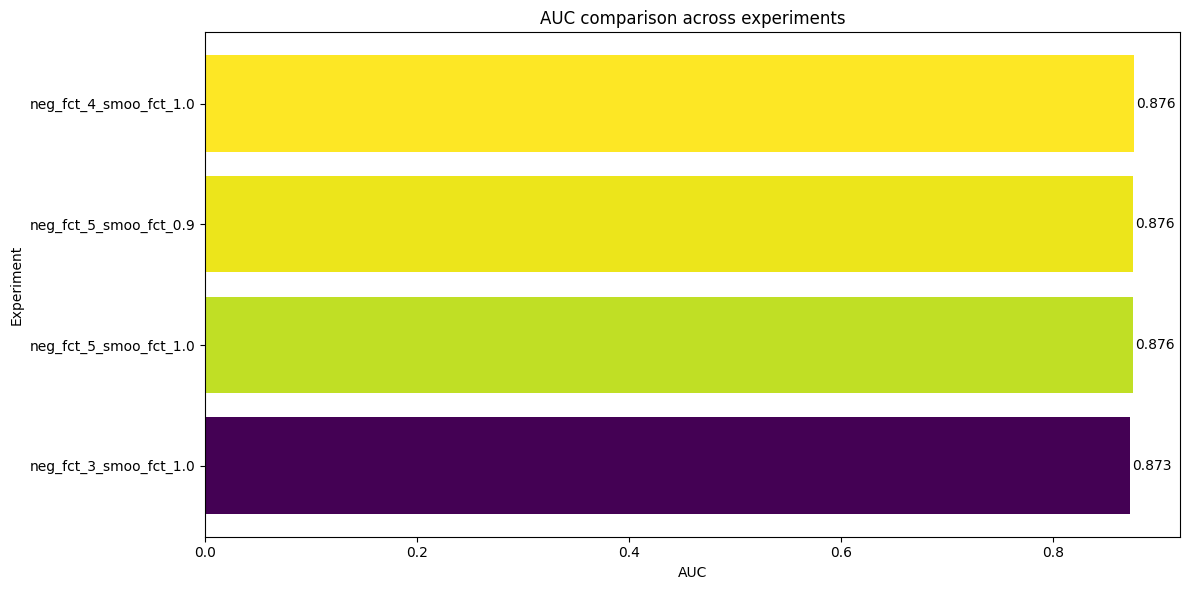

In [25]:

df = exp_df.copy()
df["folds_statistics"] = df["folds_statistics"].apply(parse_if_string)
df = df[df["folds_statistics"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 5)].copy()
metric_names = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]

for i, metric in enumerate(metric_names):
    df[metric] = df["folds_statistics"].apply(lambda x: x[i])


df["exp_clean"] = df["exp"].str.replace("dataset_", "", regex=False) # remove "dataset_" from experiment names
df = df.sort_values("AUC", ascending=True).reset_index(drop=True) # sort by AUC

# create colors according to AUC values
norm = mcolors.Normalize(vmin=df["AUC"].min(), vmax=df["AUC"].max())
colors = cm.viridis(norm(df["AUC"]))

# plotting pipeline ..
plt.figure(figsize=(12,6))
bars = plt.barh(df["exp_clean"], df["AUC"], color=colors)

plt.title("AUC comparison across experiments")
plt.xlabel("AUC")
plt.ylabel("Experiment")

for bar, value in zip(bars, df["AUC"]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [26]:
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,dataset_neg_fct_3_smoo_fct_1.0,"{""fold1"": [[0.9831123100712652, 0.958444207098...","[[0.7404227233750593, 0.6951663848414211, 0.71...","[[0.8248539350253333, 0.7521563317123322, 0.76...","[[0.9008504684473673, 0.8895046819738608, 0.87...","[[0.96270170654751, 0.9455729236416158, 0.9464...","[[0.937140101617185, 0.9345654077799741, 0.947...","[0.73221, 0.69052, 0.71428, 0.19025, 0.92337]","[0.83938, 0.76676, 0.77729, 0.26825, 0.92321]","[0.89372, 0.88079, 0.87187, 0.44849, 0.93389]","[0.96148, 0.94474, 0.94624, 0.63477, 0.96401]","[0.93634, 0.93349, 0.94576, 0.54558, 0.96859]","[0.87263, 0.84326, 0.85109, 0.41747, 0.94261]","[0.87263, 0.00664, 0.08151]"
1,dataset_neg_fct_4_smoo_fct_1.0,"{""fold1"": [[0.98738749985995, 0.95461976241106...","[[0.7848783612574812, 0.7021479882590884, 0.74...","[[0.8427420988698445, 0.7784911974621782, 0.80...","[[0.898459669609477, 0.8881022812930561, 0.910...","[[0.9520547720682905, 0.9369077458548204, 0.95...","[[0.9423809464010791, 0.9371475840686371, 0.95...","[0.74449, 0.68383, 0.71146, 0.18115, 0.92574]","[0.84188, 0.7757, 0.79597, 0.26444, 0.93268]","[0.89285, 0.88187, 0.89454, 0.4193, 0.94966]","[0.96166, 0.94685, 0.95431, 0.61635, 0.97045]","[0.94032, 0.93607, 0.94552, 0.53876, 0.96865]","[0.87624, 0.84486, 0.86036, 0.404, 0.94944]","[0.87624, 0.00604, 0.07774]"
2,dataset_neg_fct_5_smoo_fct_1.0,"{""fold1"": [[0.9881167154149739, 0.951470110779...","[[0.7514444899721586, 0.685895916916708, 0.744...","[[0.8559692015631991, 0.7932013765744989, 0.81...","[[0.9017055819557679, 0.8916297800247295, 0.93...","[[0.9645729063132261, 0.9492008529521156, 0.94...","[[0.946364561069517, 0.9420674016961431, 0.964...","[0.73492, 0.66854, 0.72565, 0.17189, 0.935]","[0.84196, 0.77362, 0.78864, 0.22312, 0.94058]","[0.8979, 0.88591, 0.91406, 0.388, 0.96351]","[0.96257, 0.94747, 0.95312, 0.6115, 0.96995]","[0.94209, 0.93816, 0.96113, 0.52805, 0.97864]","[0.87589, 0.84274, 0.86852, 0.38451, 0.95754]","[0.87589, 0.00668, 0.08174]"
3,dataset_neg_fct_5_smoo_fct_0.9,"{""fold1"": [[0.9873508685852522, 0.949280141052...","[[0.79974605975034, 0.7016714245050533, 0.7621...","[[0.8069864621024218, 0.7527253852889065, 0.81...","[[0.8745478103463807, 0.8637124331691555, 0.91...","[[0.9661304462281273, 0.9514530709014837, 0.95...","[[0.9352591539603327, 0.931924253312124, 0.968...","[0.74522, 0.66725, 0.72937, 0.17491, 0.93565]","[0.83945, 0.77923, 0.81604, 0.22015, 0.95051]","[0.89741, 0.88457, 0.92172, 0.36938, 0.96846]","[0.96334, 0.94857, 0.95768, 0.60527, 0.97321]","[0.93526, 0.93199, 0.96718, 0.51338, 0.98254]","[0.87614, 0.84232, 0.8784, 0.37662, 0.96207]","[0.87614, 0.00601, 0.07751]"


In [28]:
exp_df.to_csv(PREPROCESSED_EXP_0903_PATH, index=False)